# Kortlægning af brandopfattelse med korrespondanceanalyse (PROC CORRESP)


## Resumé

Et markedsanalyseteam gennemfører en brand-per-egenskab-opfattelsesundersøgelse på tværs af fire etablerede streaming-medie-brands og bruger **PROC CORRESP** til at omdanne den resulterende krydstabel til et todimensionelt perceptuelt kort. Sammenhængen mellem brand og egenskab er stærk og reel: chi-i-anden-testen for uafhængighed er **63,15 med 15 frihedsgrader (p < 0,0001)**, med **Cramers V = 0,4588**. Korrespondanceanalysen komprimerer den sammenhæng til to akser, der tilsammen forklarer **100 %** af tabellens inerti — **75,0 %** på dimension 1 og **25,0 %** på dimension 2 — så det 2-D-kort er et komplet, tro sammendrag.

Kortet adskiller en **premium-indholds**-pol (CineNow, forankret i *Original_Shows* og *Content_Depth*) fra en **værdi/pålidelighed**-klynge (Streamly og BingeBox nær *Affordable* og *Reliable*) og et **trendy** hjørne (PixelPlay nær *Trendy*). En ny udfordrer, **NovaCast**, projiceres derefter som et *supplementært* punkt — det påvirker ikke akserne — og lander nær origo med en let hældning mod Trendy/Easy_to_Use-siden, altså en endnu udifferentieret nykommer.


## Datakilder

| Datasæt | Rækker | Nøglevariable | Beskrivelse |
|---------|------|---------------|-------------|
| `perception` | 100 (respondent x egenskab-associationer, grænse i ulicenseret tilstand) | `Brand` (char), `Attribute` (char) | Syntetisk undersøgelse: hver respondent angiver det streaming-brand, de stærkest associerer med hver af seks egenskaber. Brand-affiniteter er kodet som `RAND("Table", ...)`-kategorisandsynligheder, så kontingenstabellen har en realistisk, ikke-uniform sammenhæng. |
| `survey_counts` | 24 (4 brands x 6 egenskaber) | `Brand`, `Attribute`, `Count` | Forhåndsaggregerede kontingensceller fra `perception` via PROC FREQ — det vægtede input til CA-kørslen med supplementært punkt. |
| `ca_coords`, `ca_coords_sup` | 10 / 11 | `_TYPE_`, `_NAME_`, `Dim1`, `Dim2` | `OUTC=`-koordinatdatasæt skrevet af PROC CORRESP; det andet tilføjer det projicerede NovaCast-punkt og driver det perceptuelle kort. |

Etablerede brands: **Streamly, PixelPlay, CineNow, BingeBox**; udfordreren **NovaCast** (projiceret som et supplementært punkt). Egenskaber: Affordable, Content_Depth, Easy_to_Use, Original_Shows, Reliable, Trendy. Kernen `streaminit(20260531)` gør data reproducerbare.

> **Bemærkning om stikprøvestørrelse.** Dette miljø kører ulicenseret, så DATA-step-output er begrænset til 100 observationer. Undersøgelsen bliver derfor til en 4x6-kontingenstabel med i alt 100 respondent-egenskab-associationer — lille, men med en ægte sammenhængsstruktur (chi-i-anden p < 0,0001), som korrespondanceanalysen genfinder rent.


## Hvad korrespondanceanalysen gør her

Når en brand-tracking-undersøgelse spørger forbrugere, hvilket brand de stærkest associerer med hver af flere egenskaber, er resultatet en **brand x egenskab-kontingenstabel**. De rå optællinger er svære at læse: hvert brand sammenlignes med hver egenskab, og signalet er *mønstret af sammenhæng*, ikke celleværdierne.

Korrespondanceanalyse (CA) dekomponerer tabellens chi-i-anden-sammenhæng i et lavdimensionelt rum, så brands og egenskaber, der er associeret, lander tæt på hinanden på ét kort. I denne notebook gør vi følgende:

1. Genererer en syntetisk opfattelsesundersøgelse for fire streaming-brands.
2. Inspicerer den rå kontingensstruktur (og dens chi-i-anden) med `PROC FREQ`.
3. Kører `PROC CORRESP` med fuld diagnostik og aflæser den reelle inerti og koordinaterne.
4. Projicerer en ny udfordrer-brand som et **supplementært** punkt.
5. Tegner og fortolker det resulterende perceptuelle kort.


## Trin 1 — Generér den syntetiske opfattelsesundersøgelse

Vi simulerer respondenter i undersøgelsen. For hver respondent spørger vi, for hver af seks egenskaber, *hvilket brand associerer du stærkest med denne egenskab?* Hvert brand har en distinkt **affinitetsprofil** — en vektor af kategorisandsynligheder, der sendes til `RAND("Table", ...)` — så f.eks. *PixelPlay* hælder mod Trendy, mens *CineNow* hælder mod Content_Depth og Original_Shows. Dette giver en kontingenstabel med en ægte, ikke-uniform sammenhæng, som CA kan genfinde. Data er fuldstændig syntetiske og reproducerbare via `CALL STREAMINIT`.


In [1]:
data perception;
    /* Reproducerbar syntetisk brandopfattelsesundersøgelse */
    CALL streaminit(20260531);

    LÆNGDE Brand $9 Attribute $14;
    TABEL attrname[6] $14 _temporary_
        ('Affordable' 'Content_Depth' 'Easy_to_Use'
         'Original_Shows' 'Reliable' 'Trendy');

    n_resp = 400;

    GØR respondent = 1 TIL n_resp;
        GØR a = 1 TIL 6;
            Attribute = attrname[a];

            /* Brand-valgssandsynligheder pr. egenskab over de
               fire etablerede brands:
               1=Streamly 2=PixelPlay 3=CineNow 4=BingeBox.
               Hver række summer til ~1 og koder egenskabens
               brand-affinitet. */
            HVIS      a = 1 SÅ b = rand('Table', 0.45, 0.15, 0.10, 0.30); /* Affordable    */
            ELLERS HVIS a = 2 SÅ b = rand('Table', 0.20, 0.10, 0.50, 0.20); /* Content_Depth */
            ELLERS HVIS a = 3 SÅ b = rand('Table', 0.30, 0.35, 0.10, 0.25); /* Easy_to_Use   */
            ELLERS HVIS a = 4 SÅ b = rand('Table', 0.15, 0.20, 0.50, 0.15); /* Original_Shows*/
            ELLERS HVIS a = 5 SÅ b = rand('Table', 0.40, 0.10, 0.20, 0.30); /* Reliable      */
            ELLERS              b = rand('Table', 0.15, 0.55, 0.10, 0.20); /* Trendy        */

            VÆLG (b);
                NÅR (1) Brand = 'Streamly';
                NÅR (2) Brand = 'PixelPlay';
                NÅR (3) Brand = 'CineNow';
                ELLERS_OM Brand = 'BingeBox';
            SLUT;

            UDDATA;
        SLUT;
    SLUT;

    BEHOLD respondent Brand Attribute;
KØR;

PROCEDURE UDSKRIV data=perception(obs=8) noobs MÆRKAT;
    MÆRKAT respondent="Respondent" Brand="Brand" Attribute="Egenskab";
    TITEL 'Uddrag af den syntetiske opfattelsesundersøgelse';
KØR;

                                    Uddrag af den syntetiske opfattelsesundersøgelse                                    

Respondent      Brand        Egenskab
         1  BingeBox   Affordable
         1  BingeBox   Content_Depth
         1  BingeBox   Easy_to_Use
         1  CineNow    Original_Shows
         1  Streamly   Reliable
         1  PixelPlay  Trendy
         2  PixelPlay  Affordable
         2  CineNow    Content_Depth

... 92 more observations (showing 8 of 100)




NOTE: DATA perception

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote perception (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.31 seconds
  cpu   0.31 seconds
NOTE: PROC PRINT data=perception

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Trin 2 — Inspicér den rå kontingenstabel

Før nogen dimensionsreduktion ser vi på krydstabellen. `PROC FREQ` giver de observerede brand x egenskab-frekvenser og chi-i-anden-testen for uafhængighed. En signifikant chi-i-anden bekræfter, at der er en sammenhængsstruktur værd at kortlægge — hvis rækker og søjler var uafhængige, ville korrespondanceanalysen intet have at vise. Vi gemmer også celleoptællingerne i `survey_counts` til CA-kørslen med supplementært punkt senere.


                                        Observerede brand x egenskab-frekvenser                                         

                                                   The FREQ Procedure

Table of Brand by Egenskab

Brand     |    Affordable | Content_Depth |   Easy_to_Use |Original_Shows |      Reliable |        Trendy |          Total
----------+---------------+---------------+---------------+---------------+---------------+---------------+---------------
BingeBox  |             5 |             3 |             7 |             1 |             6 |             2 |             24
----------+---------------+---------------+---------------+---------------+---------------+---------------+---------------
CineNow   |             3 |             9 |             0 |            14 |             2 |             0 |             28
----------+---------------+---------------+---------------+---------------+---------------+---------------+---------------
PixelPlay |             3 |             2


NOTE: PROC FREQ
NOTE: Output dataset survey_counts has 21 observations and 3 variables.
NOTE: ODS plot written: freq_mosaic_brand_attribute.spec.json
NOTE: PROC FREQ statement used.


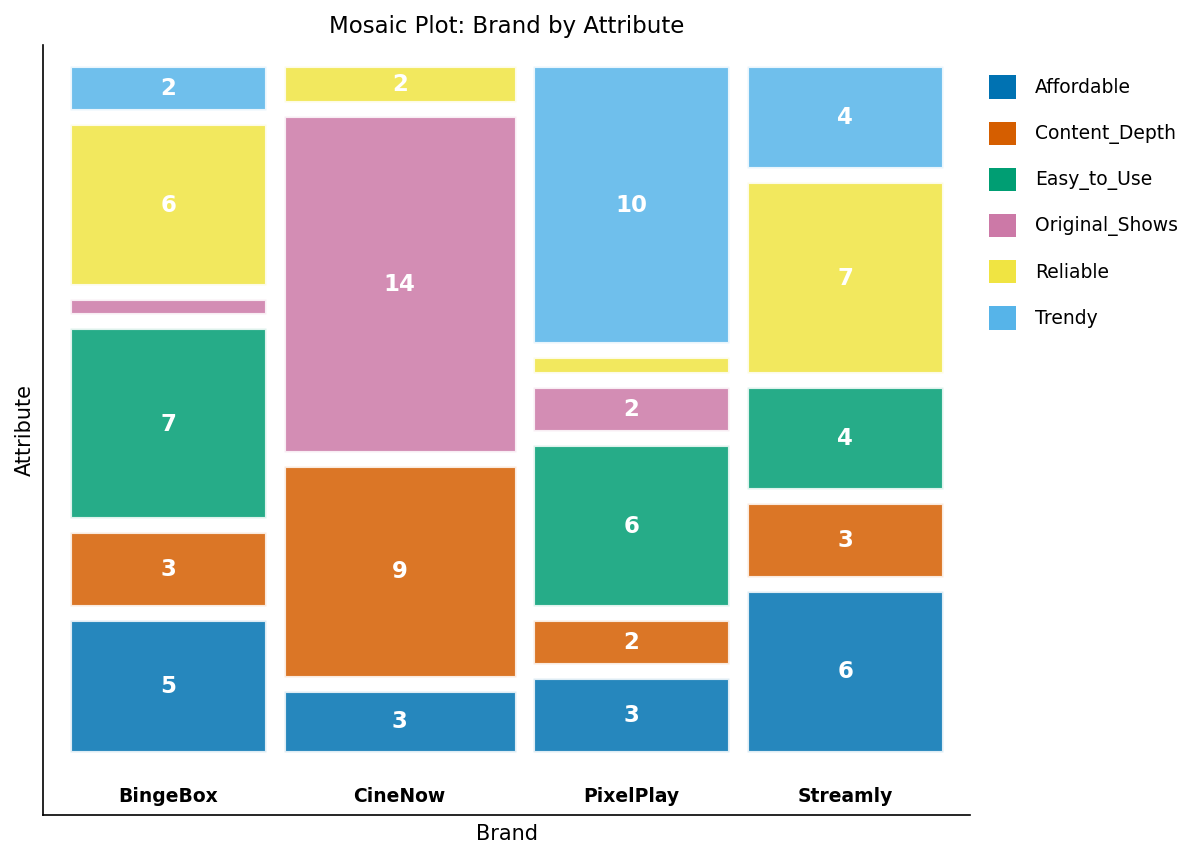

In [2]:
PROCEDURE FREKVENSER data=perception;
    TABLES Brand*Attribute / chisq norow nocol nopercent
                             out=survey_counts(OMDØB=(count=Count));
    MÆRKAT Brand="Brand" Attribute="Egenskab";
    TITEL 'Observerede brand x egenskab-frekvenser';
KØR;

## Trin 3 — Korrespondanceanalyse ud fra de rå data

Kør nu `PROC CORRESP` direkte på data på respondentniveau. `TABLES Brand, Attribute;` opbygger kontingenstabellen internt (brands som rækker, egenskaber som søjler).

Optioner brugt her:

- `ALL` — udskriv den fulde diagnostik: observeret tabel, profiler, forventede værdier og   cellernes chi-i-anden-bidrag.
- `DIMENS=2` — beregn de første to hovedakser (et 2-D-kort).
- `OUTC=` — skriv række- og søjlekoordinater til et datasæt til plotning.

**Inertidekompositionen** fortæller os, hvor meget af den samlede sammenhæng hver akse forklarer.


In [3]:
PROCEDURE corresp data=perception ALL dimens=2 outc=ca_coords;
    TABLES Brand, Attribute;
    MÆRKAT Brand="Brand" Attribute="Egenskab";
    TITEL 'Korrespondanceanalyse: opfattelse af streaming-brands';
KØR;

                                        Observerede brand x egenskab-frekvenser                                         

                     The CORRESP Procedure

              Inertia and Chi-Square Decomposition

                                                       Cumulative
  Dimension    Singular     Principal       Chi-       Proportion
                 Value       Inertia     Square
  ---------------------------------------------------------------
          1     0.6778       0.4595       47.39          0.7504
          2     0.3909       0.1528       15.76          1.0000
  ---------------------------------------------------------------
  Total                      0.6123       63.15

              Row Coordinates

  Brand                   Dim1        Dim2
  ----------------------------------------
  BingeBox             0.3547      0.3555
  CineNow             -1.0847     -0.0332
  PixelPlay            0.4804     -0.6374
  Streamly             0.4304      0.3207

       


NOTE: PROC CORRESP data=perception

NOTE: PROC CORRESP completed.


## Trin 4 — Aflæs koordinaterne

`OUTC=`-datasættet indeholder aksekoordinaterne (`Dim1`, `Dim2`) for hvert brand og hver egenskab, mærket med `_TYPE_` (`ROW` for brands, `COLUMN` for egenskaber). At aflæse dem numerisk sammen med inertitabellen bekræfter den struktur, kortet vil vise.

Fra outputtet ovenfor:

- **Dimension 1 (75,0 % af inertien)** er en akse for *premium-indhold vs. mainstream*.   *Original_Shows* (Dim1 = -1,2037) og *Content_Depth* (-0,5594) ligger i den negative   ende med **CineNow** (-1,0847); *Trendy* (0,6671), *Easy_to_Use* (0,6150) og   *Affordable* (0,2207) ligger i den positive ende.
- **Dimension 2 (25,0 % af inertien)** adskiller *Reliable* (Dim2 = 0,5874) og   *Affordable* (0,2542) — som trækker **Streamly** (0,3207) og **BingeBox** (0,3555) opad —   fra *Trendy* (-0,7003), som trækker **PixelPlay** (-0,6374) nedad.


In [4]:
PROCEDURE UDSKRIV data=ca_coords noobs MÆRKAT;
    VARIABEL _TYPE_ _NAME_ Dim1 Dim2;
    MÆRKAT _TYPE_="Type" _NAME_="Navn" Dim1="Dim1" Dim2="Dim2";
    TITEL 'Række- (brand) og søjle- (egenskab) koordinater';
KØR;

                                    Række- (brand) og søjle- (egenskab) koordinater                                     

  Type              Navn      Dim1      Dim2
ROW     BingeBox            0.3547    0.3555
ROW     CineNow            -1.0847   -0.0332
ROW     PixelPlay           0.4804   -0.6374
ROW     Streamly            0.4304    0.3207
COLUMN  Affordable          0.2207    0.2542
COLUMN  Content_Depth      -0.5594    0.0684
COLUMN  Easy_to_Use         0.6150   -0.0080
COLUMN  Original_Shows     -1.2037   -0.2084
COLUMN  Reliable            0.3183    0.5874
COLUMN  Trendy              0.6671   -0.7003




NOTE: PROC PRINT data=ca_coords

NOTE: PROC PRINT completed: 10 observations printed, 4 variables


## Trin 5 — Projicér en udfordrer-brand som et supplementært punkt

Analyseteamet har tracking-data for en ny udfordrer, **NovaCast**, men ønsker ikke, at den forvrider det etablerede perceptuelle kort. Et *supplementært* punkt projiceres ind i det eksisterende CA-rum **uden at bidrage til akseberegningen**.

Vi tilføjer en enkelt blok med seks NovaCast-egenskabsoptællinger (en nykommer, der hælder mod Trendy/Original-Shows) til de forhåndsaggregerede `survey_counts`, tilfører frekvenserne med `WEIGHT Count` og navngiver **niveauet** `NovaCast` på `SUPPLEMENTARY`-sætningen, så PROC CORRESP holder den række uden for den aktive tabel. `OBSERVED`-optionen holder den aktive kontingenstabel (de fire etablerede brands, med sum 100) synlig — bemærk at NovaCast **ikke** optræder i den, hvilket bekræfter, at den blev behandlet som supplementær.


In [5]:
/* Tilføj ÉN ren blok med NovaCast-optællinger til de aggregerede celler.
   end=last udløses præcis én gang, efter den sidste survey_counts-række,
   så NovaCast bidrager med seks rækker (en pr. egenskab) -- ikke en gentaget
   blok. NovaCast er en nykommer ledet af Trendy / Original-Shows. */
data survey_counts_sup;
    SÆT survey_counts SLUT=last;
    UDDATA;
    HVIS last SÅ GØR;
        Brand='NovaCast'; Attribute='Trendy';          Count=10; UDDATA;
        Brand='NovaCast'; Attribute='Original_Shows';  Count=8;  UDDATA;
        Brand='NovaCast'; Attribute='Easy_to_Use';     Count=5;  UDDATA;
        Brand='NovaCast'; Attribute='Content_Depth';   Count=3;  UDDATA;
        Brand='NovaCast'; Attribute='Affordable';      Count=4;  UDDATA;
        Brand='NovaCast'; Attribute='Reliable';        Count=3;  UDDATA;
    SLUT;
KØR;

PROCEDURE corresp data=survey_counts_sup observed dimens=2 outc=ca_coords_sup;
    TABLES Brand, Attribute;
    VÆGT Count;
    supplementary NovaCast;
    MÆRKAT Brand="Brand" Attribute="Egenskab";
    TITEL 'Brandopfattelse med NovaCast som supplementært punkt';
KØR;

                                    Række- (brand) og søjle- (egenskab) koordinater                                     

                     The CORRESP Procedure

              Inertia and Chi-Square Decomposition

                                                       Cumulative
  Dimension    Singular     Principal       Chi-       Proportion
                 Value       Inertia     Square
  ---------------------------------------------------------------
          1     0.6778       0.4595       47.39          0.7504
          2     0.3909       0.1528       15.76          1.0000
  ---------------------------------------------------------------
  Total                      0.6123       63.15

              Row Coordinates

  Brand                   Dim1        Dim2
  ----------------------------------------
  BingeBox             0.3547      0.3555
  CineNow             -1.0847     -0.0332
  PixelPlay            0.4804     -0.6374
  Streamly             0.4304      0.3207
  NovaCa


NOTE: DATA survey_counts_sup


NOTE: Read 21 rows from survey_counts.
NOTE: Wrote survey_counts_sup (27 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC CORRESP data=survey_counts_sup

NOTE: PROC CORRESP completed.


## Trin 6 — Tegn det perceptuelle kort

PROC CORRESP skriver de symmetriske række-/søjlekoordinater til `OUTC=`-datasættet; vi plotter dimension 2 mod dimension 1 for at gengive kortet. Vi mærker hvert punkt efter **rolle** — *Brand* (aktive rækker), *Attribute* (søjler) og *Challenger* (den supplementære NovaCast-række) — og påfører etiket på hver markør, så placeringen kan aflæses direkte på plottet. Udfordreren er farvet separat for at understrege, at den blev projiceret ind, ikke tilpasset.

> **Sådan læses et CA-kort.** Et brand og en egenskab, der ligger i samme retning fra origo (og langt fra det), er stærkt associerede; punkter nær origo er "gennemsnitlige" og svagt differentierede. Fordi dimension 1 og 2 tilsammen fanger 100 % af denne tabels inerti, udelader kortet intet.


                       Kort over streaming-brandopfattelse (Dim1 75,0 %, Dim2 25,0 % af inertien)                       

PROC SGSCATTER Output
Data: ca_map

Variables: Role, _NAME_, Dim1, Dim2

      Role      _NAME_        Dim1        Dim2
----------  ----------  ----------  ----------
     Brand    BingeBox      0.3547      0.3555
     Brand     CineNow     -1.0847     -0.0332
     Brand   PixelPlay      0.4804     -0.6374
     Brand    Streamly      0.4304      0.3207
Challenger    NovaCast      0.0084     -0.1735
 Attribute  Affordable      0.2207      0.2542
 Attribute  Content_Depth     -0.5594      0.0684
 Attribute  Easy_to_Use       0.615      -0.008
 Attribute  Original_Shows     -1.2037     -0.2084
 Attribute    Reliable      0.3183      0.5874
 Attribute      Trendy      0.6671     -0.7003

Dim1: N=11, Min=-1.2037, Max=0.6671, Mean=0.0225, Sum=0.2472
Dim2: N=11, Min=-0.7003, Max=0.5874, Mean=-0.0159, Sum=-0.1746



NOTE: DATA ca_map


NOTE: Read 11 rows from ca_coords_sup.
NOTE: Wrote ca_map (11 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Kort over streaming-brandopfattelse (Dim1 75,0 %, Dim2 25,0 % af inertien).
NOTE: ODS Graphics is ON (width=760px, height=580px, format=SVG).
NOTE: PROC SGSCATTER data=ca_map

NOTE: PROC SGSCATTER output written to: ./ods_output/sgscatter.svg
NOTE: ODS Graphics is OFF.


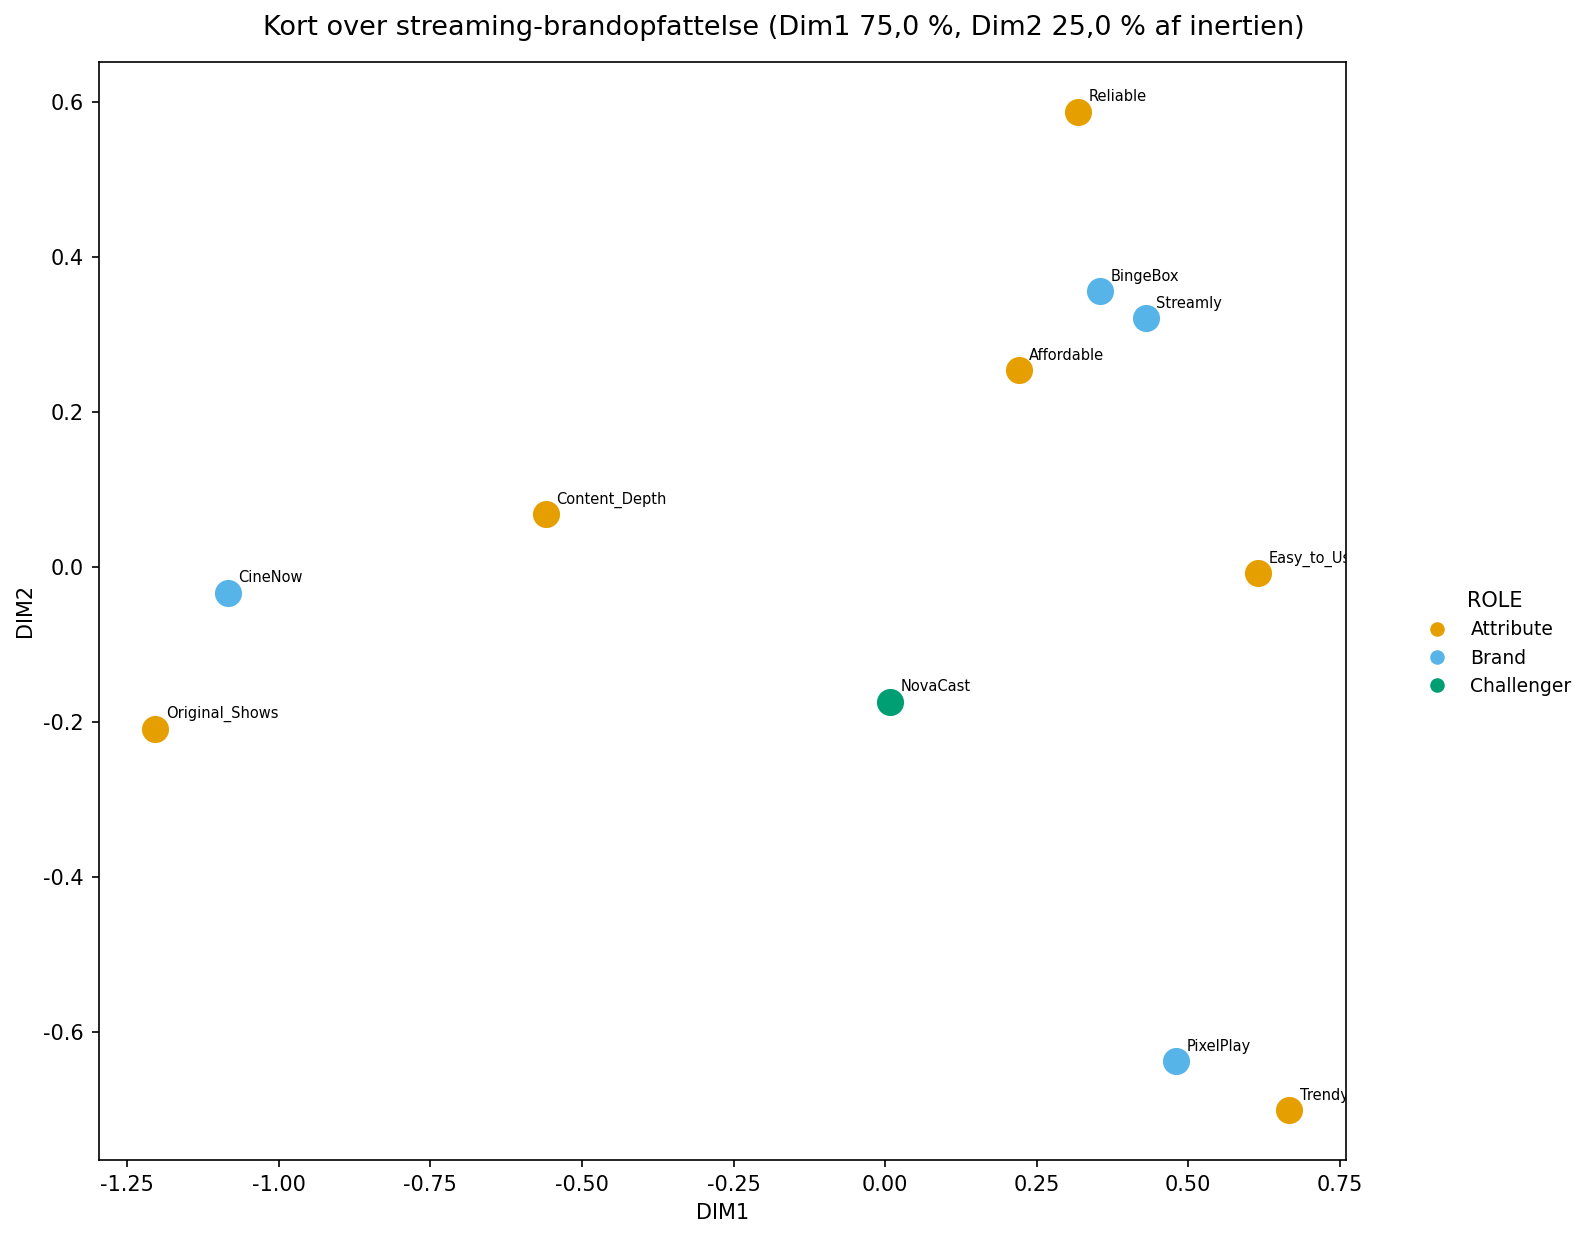

In [6]:
/* Mærk hvert OUTC-punkt efter rolle til en ren, farvet forklaring.
   Supplementære NovaCast skrives til OUTC med _TYPE_='ROW',
   så vi behandler den som et særtilfælde: udfordreren (Challenger). */
data ca_map;
    SÆT ca_coords_sup;
    LÆNGDE Role $10;
    HVIS _NAME_ = 'NovaCast' SÅ Role = 'Challenger';
    ELLERS HVIS _TYPE_ = 'ROW' SÅ Role = 'Brand';
    ELLERS Role = 'Attribute';
    BEHOLD Role _NAME_ Dim1 Dim2;
KØR;

/* Sæt kortets titel globalt før proceduren, så den titulerer dette
   plot (den globale TITEL-sætning driver ODS-grafikkens overskrift). */
TITEL 'Kort over streaming-brandopfattelse (Dim1 75,0 %, Dim2 25,0 % af inertien)';

ODS GRAPHICS ON / WIDTH=760px HEIGHT=580px;

/* PROC CORRESP har intet indbygget ODS-kort i denne build, så vi
   gengiver de symmetriske koordinater med PROC SGSCATTER, som mærker hvert punkt. */
PROCEDURE SGSCATTER data=ca_map;
    PLOT Dim2*Dim1 / GROUP=Role DATALABEL=_NAME_
                     MARKERATTRS=(size=12) grid;
KØR;

ODS GRAPHICS OFF;
TITEL;

## Fortolkning af resultaterne

**Sammenhængen er reel og fuldt fanget.** Chi-i-anden-testen (63,15 med 15 frihedsgrader, p < 0,0001; Cramers V = 0,4588) forkaster uafhængighed, og de to CA-dimensioner forklarer **100 %** af tabellens inerti (75,0 % + 25,0 %), så kortet nedenfor er et komplet sammendrag, ikke en tabsbehæftet projektion.

**Tre perceptuelle territorier.** Aflæst ud fra koordinaterne og kortet tilsammen:

- **Premium-indhold (venstre).** *CineNow* (Dim1 = -1,0847) trækkes langt til venstre af   *Original_Shows* (-1,2037) og *Content_Depth* (-0,5594) — det ejer   opfattelsen af katalogdybde.
- **Værdi og pålidelighed (øverst til højre).** *Streamly* (0,4304, 0,3207) og *BingeBox*   (0,3547, 0,3555) klynger sig sammen med *Affordable* (0,2207, 0,2542) og *Reliable* (0,3183,   0,5874) — det pålidelige par med god værdi.
- **Trendy (nederst til højre).** *PixelPlay* (0,4804, -0,6374) ligger ved siden af *Trendy*   (0,6671, -0,7003) — det ungdommelige, tidssvarende brand.

**Den supplementære udfordrer.** Projiceret uden at påvirke akserne lander **NovaCast** på (0,0084, -0,1735) — stort set i origo, skubbet mod Trendy/Easy_to_Use-siden. For en mediestrateg er det hovedbudskabet: udfordreren har endnu ingen distinktiv brandværdi og driver ind i PixelPlays trendy territorium, så en differentieret positionering (frem for en efterlignende) er berettiget.

**Forbehold.** Korrespondanceanalyse er beskrivende, ikke inferentiel — afstande er tilnærmede, og aksernes *fortegn* er vilkårlige (en spejlvending af en akse giver det samme kort). Med kun 100 respondent-egenskab-associationer er to celler nul (CineNow x Easy_to_Use, Streamly x Original_Shows), hvilket skærper yderpunkterne; et produktionsstudie ville indhente en større stikprøve. Par altid kortet med inertitabellen for at bekræfte, hvor meget sammenhæng de viste dimensioner forklarer.
